# FIGS-W — Wildfire Case Analysis & Display

Run a forecast for a HRRR cycle, render SPC fire-weather-style probability /
categorical / size maps, and overlay the observed
(NIFC + IEM) active fires. Mirrors FIGS notebook 1.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs_w` works from notebooks/
from figs_w import config as C

In [2]:
from datetime import datetime, timezone, timedelta
from figs_w.model.predict import predict_or_load
from figs_w.products import plots, cig
from figs_w.data import fire_reports
from figs.products import summary           # generic day-max / median-bin helpers
from figs.data import grid

# RUN        = datetime(2021, 12, 15, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN        = datetime(2025, 3, 14, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN        = datetime(2024, 2, 27, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
RUN   = datetime(2026, 6, 26, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# FXX        = list(range(1, 19))                              # forecast hours
FXX   = list(range(1, 13)) # 18z runs for 19-06z                              # forecast hours
MODELS     = None                                            # None -> Data/figs_w/models
DL_WORKERS = 8                                               # forecast hours downloaded concurrently

## Predict

`predict_or_load` assembles the single-run HRRR state + static geography per
forecast hour, returning `p_wildfire` and the conditional size distribution
`dist_wildfire` (5 acreage bins). Results are cached as netCDF so repeat runs
skip the download.

In [3]:
try:
    preds = predict_or_load(RUN, FXX, models_dir=MODELS, workers=DL_WORKERS)
    print(f'{len(preds)} forecast hours')
except Exception as e:
    print('predict failed (need trained models?):', e); preds = None

[predict-w] f01 done
[predict-w] f05 done
[predict-w] f02 done
[predict-w] f03 done
[predict-w] f08 done
[predict-w] f06 done
[predict-w] f07 done
[predict-w] f04 done
[predict-w] f09 done
[predict-w] f10 done
[predict-w] f11 done
[predict-w] f12 done
[predict-w] saved to /Users/jwt/Documents/Code/FIGS/Data/figs_w/products/figs_w_20260626_18Z_f01-12.nc
12 forecast hours


## Map extent

Plan-view extent `[lon_min, lon_max, lat_min, lat_max]` for ALL plots below.

In [8]:
# MAP_EXTENT = [-105, -90, 30, 45] # Plains
MAP_EXTENT = [-120, -100, 30, 50]  # western CONUS
plots.set_extent(MAP_EXTENT)

## Per-forecast-hour fire-weather maps — animated over the period

Looping GIFs over every forecast hour: probability+CIG and the fire-weather
categorical (NONE / ELEVATED / CRITICAL / EXTREME).

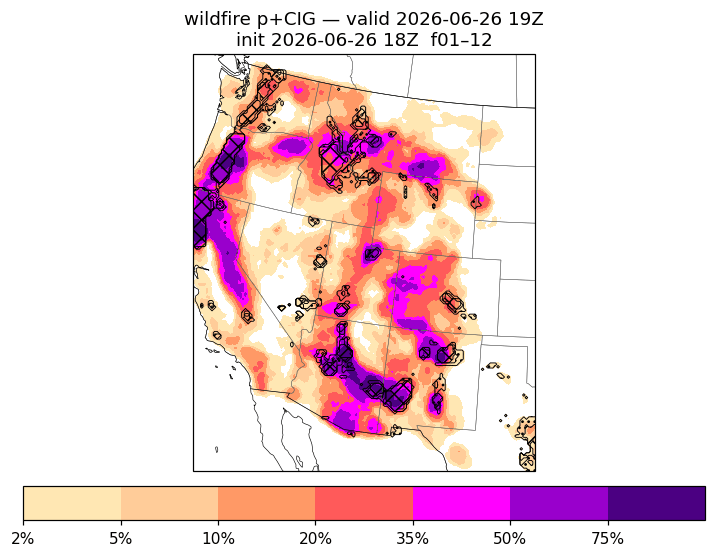

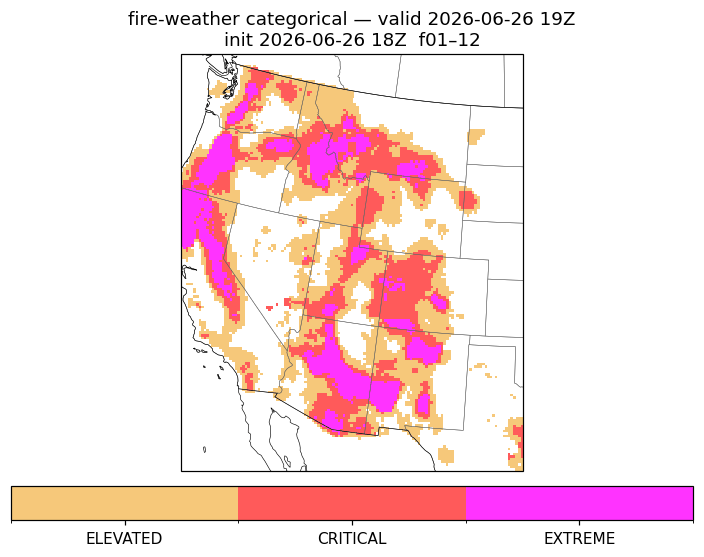

In [9]:
if preds:
    from IPython.display import Image, display
    from figs.products import animate
    prob_frames, cat_frames = [], []
    for f in sorted(FXX):
        p = preds[f]['p_wildfire']; dist = np.nan_to_num(preds[f]['dist_wildfire'])
        cig_idx = cig.derive_cig_category('wildfire', dist)
        cat = cig.prob_to_category('wildfire', p*100,
                                   np.where(p >= C.SPC_PROB_LEVELS['wildfire'][0], cig_idx, 0))
        vt = RUN + timedelta(hours=f)
        ttl = f'valid {vt:%Y-%m-%d %HZ}'
        prob_frames.append(plots.plot_probability(p, f'wildfire p+CIG — {ttl}', f'/tmp/_w_p_{f:02d}.png', cig=cig_idx))
        cat_frames.append(plots.plot_categorical(cat, f'fire-weather categorical — {ttl}', f'/tmp/_w_c_{f:02d}.png'))
    display(Image(animate.make_gif(prob_frames, '/tmp/_w_p.gif', duration_ms=600)))
    display(Image(animate.make_gif(cat_frames, '/tmp/_w_c.gif', duration_ms=600)))

## Day-total: probability, categorical, day-max median size

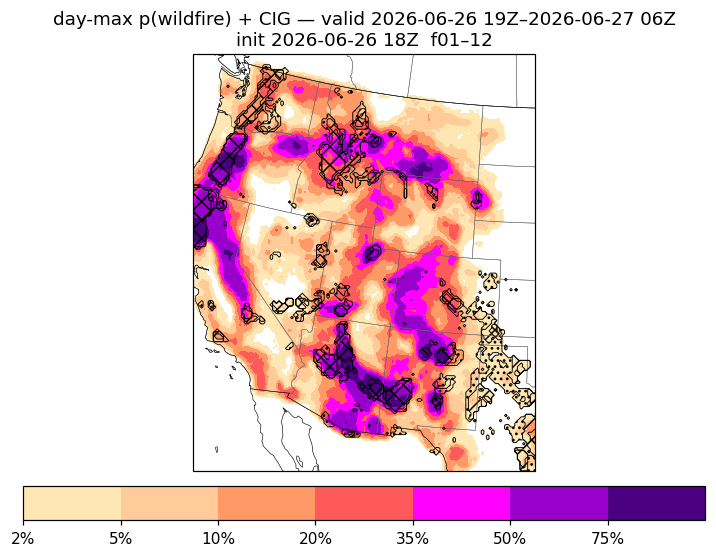

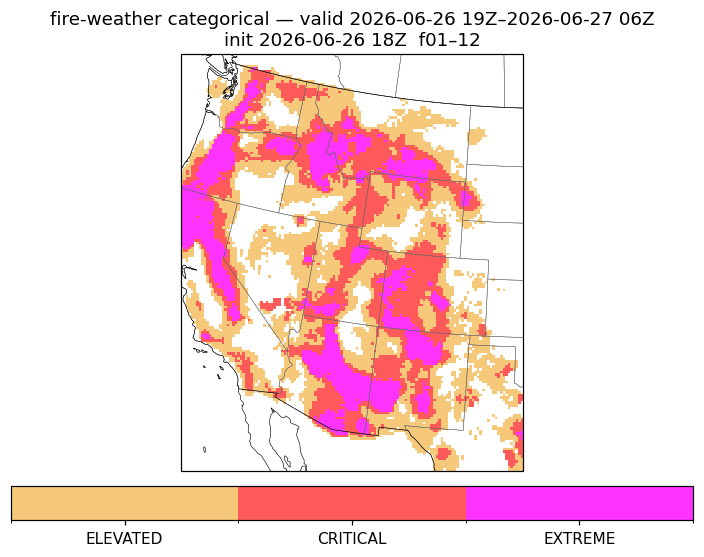

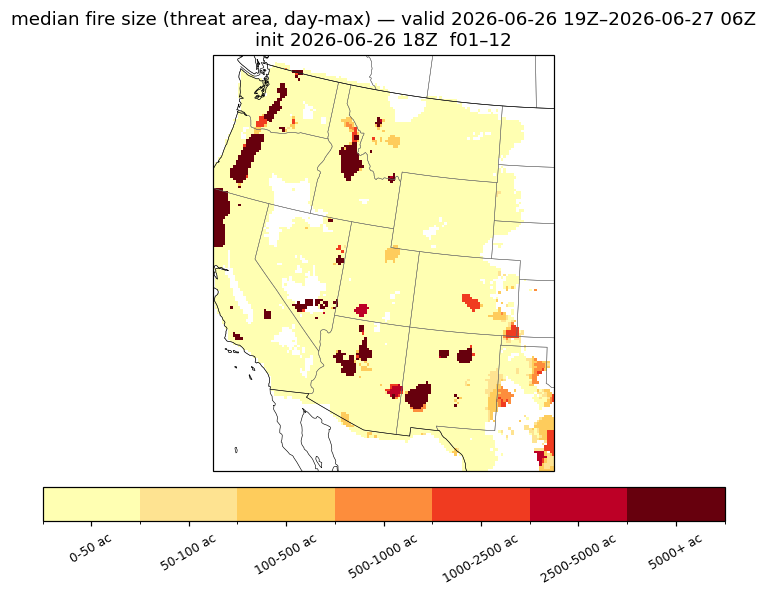

In [10]:
if preds:
    from IPython.display import Image, display
    v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
    period = f'valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}'
    pmax  = summary.day_max({f: preds[f]['p_wildfire'] for f in FXX})
    cigmax = np.stack([cig.derive_cig_category('wildfire', np.nan_to_num(preds[f]['dist_wildfire'])) for f in FXX]).max(axis=0)
    cat = cig.prob_to_category('wildfire', pmax*100, np.where(pmax >= C.SPC_PROB_LEVELS['wildfire'][0], cigmax, 0))
    plots.plot_probability(pmax, f'day-max p(wildfire) + CIG — {period}', '/tmp/_w_pmax.png', cig=cigmax); display(Image('/tmp/_w_pmax.png'))
    plots.plot_categorical(cat, f'fire-weather categorical — {period}', '/tmp/_w_catmax.png'); display(Image('/tmp/_w_catmax.png'))
    # day-max median conditional size bin, masked to the threat area
    med = np.stack([summary.median_intensity_bin(np.nan_to_num(preds[f]['dist_wildfire'])) for f in FXX]).max(axis=0)
    med = np.where(pmax >= C.SPC_PROB_LEVELS['wildfire'][0], med, -1)
    plots.plot_intensity(med, f'median fire size (threat area, day-max) — {period}', '/tmp/_w_size.png'); display(Image('/tmp/_w_size.png'))

## Forecast vs observed fires

Overlay the active NIFC + IEM fire footprints over the valid window on the
day-max probability.

14 active-fire footprint points in window


AttributeError: module 'figs_w.products.plots' has no attribute '_with_run'

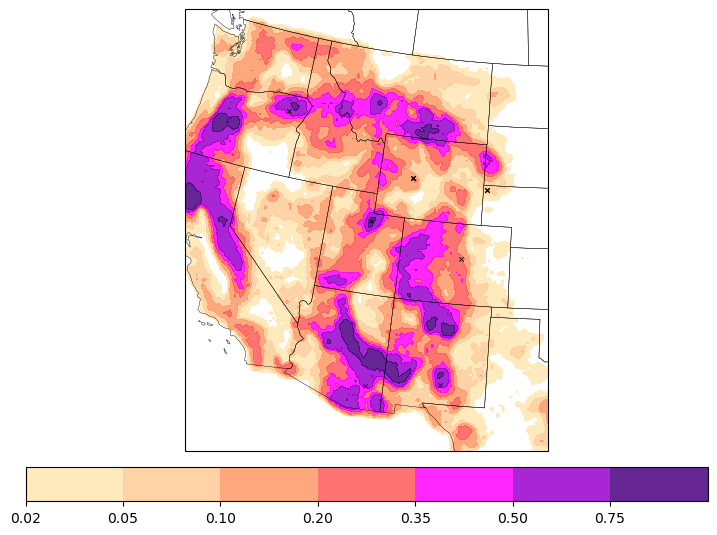

In [11]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
if preds:
    lat, lon = grid.figs_latlon()
    v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
    # collect active-fire footprint points across the valid window (hourly)
    pts = []
    h = v0
    while h <= v1:
        for p_xy, *_ in fire_reports.active_fires(h):
            pts.append(np.atleast_2d(p_xy))
        h += timedelta(hours=3)
    pts = np.vstack(pts) if pts else np.empty((0,2))
    print(len(pts), 'active-fire footprint points in window')
    pmax = summary.day_max({f: preds[f]['p_wildfire'] for f in FXX})
    lv = list(C.SPC_PROB_LEVELS['wildfire']) + [1.0]
    proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
    fig = plt.figure(figsize=(11,7)); ax = plt.axes(projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
    cf = ax.contourf(lon, lat, pmax, levels=lv, colors=plots.PROB_COLORS['wildfire'], transform=ccrs.PlateCarree(), alpha=0.85, extend='neither')
    plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, ticks=C.SPC_PROB_LEVELS['wildfire'])
    if len(pts): ax.scatter(pts[:,1], pts[:,0], s=10, c='black', marker='x', lw=0.6, transform=ccrs.PlateCarree(), label='observed fire')
    ax.set_title(plots._with_run(f'FIGS-W day-max p(wildfire) vs observed fires — valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}')); ax.legend(loc='lower right'); plt.show()